In [1]:
import pandas as pd #for data handling
import numpy as np
import matplotlib.pyplot as plt #for EDA
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, roc_curve, auc, classification_report
#using sklearn for pipelining
# Set style for plots
sns.set(style="whitegrid")

In [2]:
df = pd.read_csv('HeartDiseaseTrain-Test.csv')

# Handle missing values
print("Missing values per column:\n", df.isnull().sum())
df = df.dropna() # Standard cleaning practice

# Display first few rows
df.head()

Missing values per column:
 age                              0
sex                              0
chest_pain_type                  0
resting_blood_pressure           0
cholestoral                      0
fasting_blood_sugar              0
rest_ecg                         0
Max_heart_rate                   0
exercise_induced_angina          0
oldpeak                          0
slope                            0
vessels_colored_by_flourosopy    0
thalassemia                      0
target                           0
dtype: int64


,age,sex,chest_pain_type,resting_blood_pressure,cholestoral,fasting_blood_sugar,rest_ecg,Max_heart_rate,exercise_induced_angina,oldpeak,slope,vessels_colored_by_flourosopy,thalassemia,target
0,52,Male,Typical angina,125,212,Lower than 120 mg/ml,ST-T wave abnormality,168,No,1.0,Downsloping,Two,Reversable Defect,0
1,53,Male,Typical angina,140,203,Greater than 120 mg/ml,Normal,155,Yes,3.1,Upsloping,Zero,Reversable Defect,0
2,70,Male,Typical angina,145,174,Lower than 120 mg/ml,ST-T wave abnormality,125,Yes,2.6,Upsloping,Zero,Reversable Defect,0
3,61,Male,Typical angina,148,203,Lower than 120 mg/ml,ST-T wave abnormality,161,No,0.0,Downsloping,One,Reversable Defect,0
4,62,Female,Typical angina,138,294,Greater than 120 mg/ml,ST-T wave abnormality,106,No,1.9,Flat,Three,Fixed Defect,0


In [4]:
categorical_cols = ['sex', 'chest_pain_type', 'fasting_blood_sugar', 'rest_ecg', 'exercise_induced_angina', 'slope', 'vessels_colored_by_flourosopy', 'thalassemia']
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)


I've created a new DataFrame `df_encoded` where categorical columns are converted to numerical format using one-hot encoding. Now, the correlation heatmap can be generated correctly.

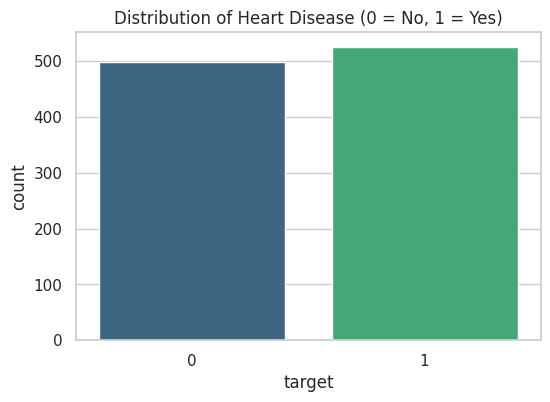

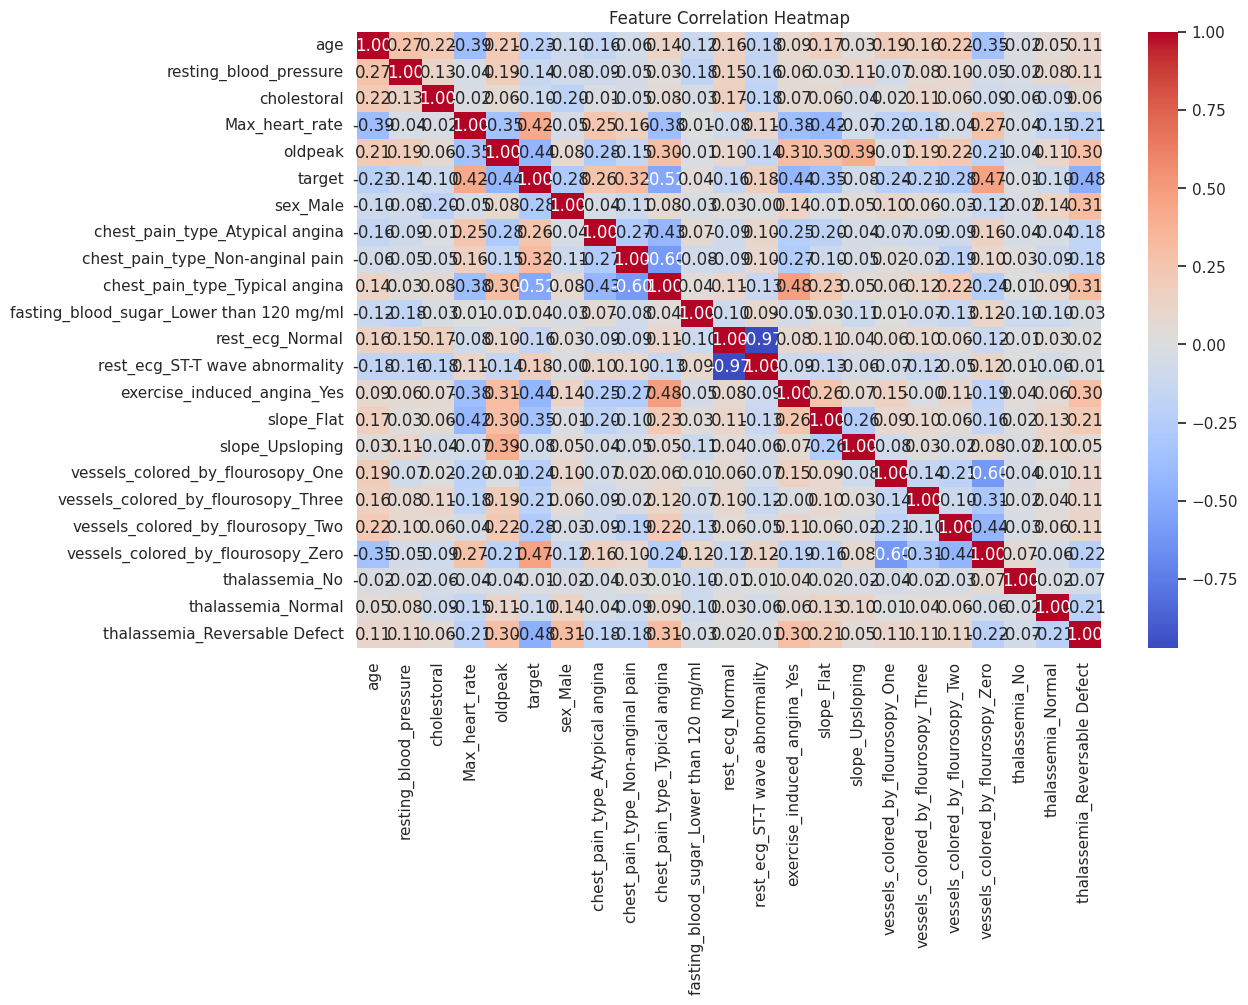

In [5]:
# Check distribution of the target variable
plt.figure(figsize=(6,4))
sns.countplot(x='target', data=df, palette='viridis', hue='target', legend=False)
plt.title('Distribution of Heart Disease (0 = No, 1 = Yes)')
plt.show()

# Heatmap for correlations
plt.figure(figsize=(12,8))
sns.heatmap(df_encoded.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Feature Correlation Heatmap')
plt.show()

In [9]:
# Assuming 'target' is the column name for the diagnosis
X = df_encoded.drop('target', axis=1)
y = df_encoded['target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training set size: {X_train.shape[0]}")
print(f"Testing set size: {X_test.shape[0]}")

Training set size: 820
Testing set size: 205


In [10]:
# Initialize and train
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

# Make predictions
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1] # Probability for ROC curve

print("Model Training Complete.")

Model Training Complete.


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Model Accuracy: 81.46%


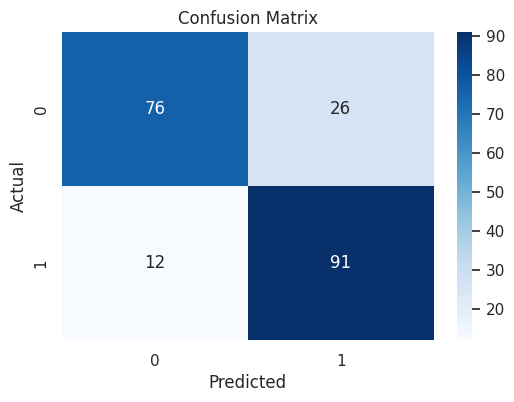


Classification Report:
               precision    recall  f1-score   support

           0       0.86      0.75      0.80       102
           1       0.78      0.88      0.83       103

    accuracy                           0.81       205
   macro avg       0.82      0.81      0.81       205
weighted avg       0.82      0.81      0.81       205



In [12]:
# Accuracy Score
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy * 100:.2f}%")

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

print("\nClassification Report:\n", classification_report(y_test, y_pred))

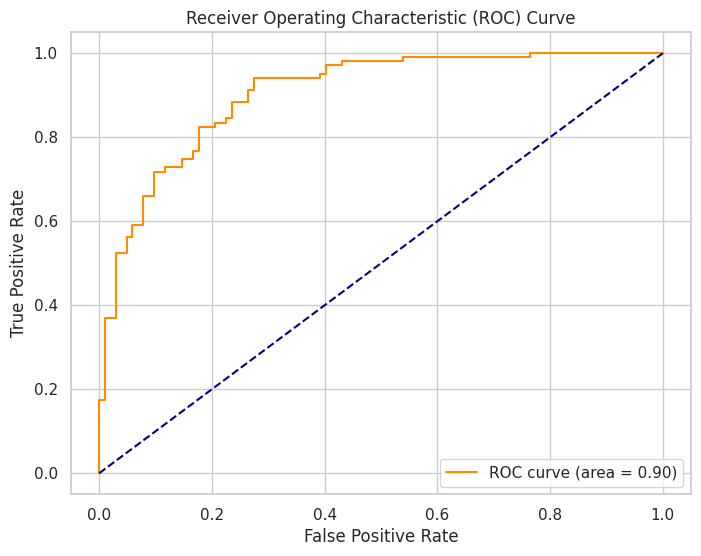

In [13]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, color='darkorange', label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()

/tmp/ipykernel_1619/909519305.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_importance, palette='magma')


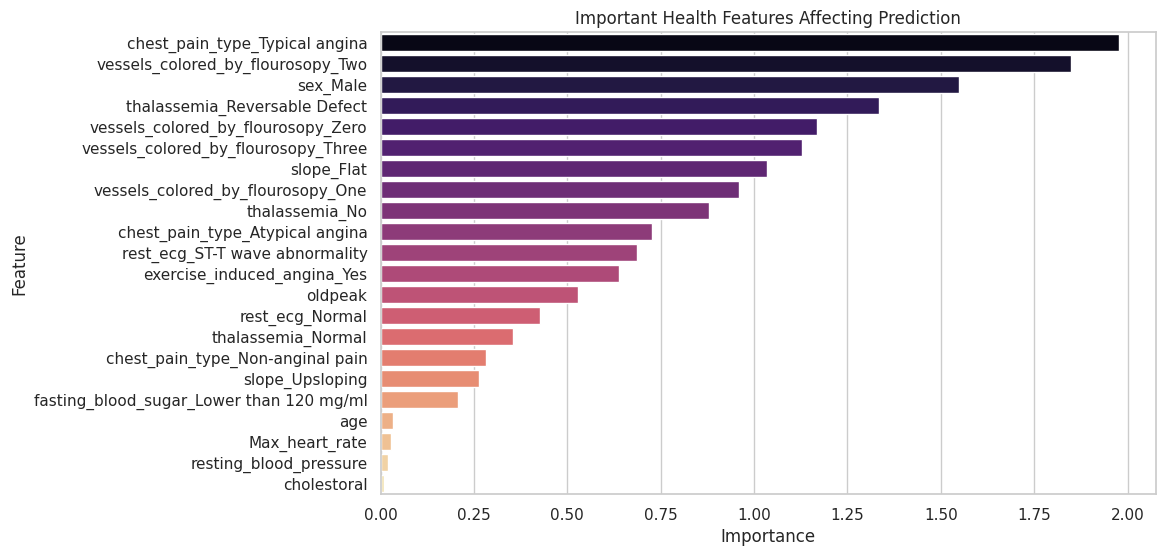

In [14]:
importance = np.abs(model.coef_[0])
feature_names = X.columns
feature_importance = pd.DataFrame({'Feature': feature_names, 'Importance': importance})
feature_importance = feature_importance.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(x='Importance', y='Feature', data=feature_importance, palette='magma')
plt.title('Important Health Features Affecting Prediction')
plt.show()

In [17]:
print("Enter Patient Details for Prediction:")

# Note: The inputs should match the columns in your CSV (e.g., age, sex, cp, trestbps, etc.)
# We create a dictionary to hold the inputs
user_data = {}
for feature in X.columns:
    val = float(input(f"Enter value for {feature}: "))
    user_data[feature] = [val]

# Convert to DataFrame
user_df = pd.DataFrame(user_data)

# Prediction
prediction = model.predict(user_df)
probability = model.predict_proba(user_df)[0][1]

print("\n--- Results ---")
if prediction[0] == 1:
    print(f"Risk Detected: High Risk of Heart Disease.")
    print(f"Confidence Level: {probability*100:.2f}%")
else:
    print(f"Risk Detected: Low Risk / No Heart Disease.")
    print(f"Confidence Level: {(1-probability)*100:.2f}%")

Enter Patient Details for Prediction:
Enter value for age: 21
Enter value for resting_blood_pressure: 120
Enter value for cholestoral: 89
Enter value for Max_heart_rate: 99
Enter value for oldpeak: 140
Enter value for sex_Male: 1
Enter value for chest_pain_type_Atypical angina: 1
Enter value for chest_pain_type_Non-anginal pain: 1
Enter value for chest_pain_type_Typical angina: 1
Enter value for fasting_blood_sugar_Lower than 120 mg/ml: 90
Enter value for rest_ecg_Normal: 20
Enter value for rest_ecg_ST-T wave abnormality: 1
Enter value for exercise_induced_angina_Yes: 1
Enter value for slope_Flat: 1
Enter value for slope_Upsloping: 1
Enter value for vessels_colored_by_flourosopy_One: 1
Enter value for vessels_colored_by_flourosopy_Three: 1
Enter value for vessels_colored_by_flourosopy_Two: 1
Enter value for vessels_colored_by_flourosopy_Zero: 1
Enter value for thalassemia_No: 1
Enter value for thalassemia_Normal: 1
Enter value for thalassemia_Reversable Defect: 1

--- Results ---
Risk 